<a href="https://colab.research.google.com/github/yanhyee/SIT-UofG-QC-Assignment/blob/main/BB84-Attacker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 62.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=8491a7fdb02af54488eb53b4df8913475f445434497ed0c35c8514ae878d5d1f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

## Step 1: Helper functions

All random choices are generated by measuring $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$, not by using Python's random module.

In [3]:
# Helper functions used by both versions of BB84
# IMPORTANT: Random choices are generated by measuring |+> = (|0> + |1>) / sqrt(2).
# This follows the assignment requirement not to use Python's random number generator.

backend = BasicSimulator()

def quantum_random_bit():
    """Return one random bit by preparing |+> and measuring it."""
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))


def quantum_random_bits(n):
    """Return n random bits generated quantum mechanically."""
    return [quantum_random_bit() for _ in range(n)]


def basis_name(basis):
    """0 means computational/rectilinear basis (+); 1 means diagonal basis (x)."""
    return '+' if basis == 0 else 'x'


def bit_list_to_string(bits):
    return ''.join(str(bit) for bit in bits)


def encode_qubit(bit, basis):
    """
    Alice encodes one classical bit into one qubit.

    basis = 0: computational basis
        bit 0 -> |0>
        bit 1 -> |1>

    basis = 1: diagonal basis
        bit 0 -> |+>
        bit 1 -> |->
    """
    qc = QuantumCircuit(1, 1)

    if bit == 1:
        qc.x(0)

    if basis == 1:
        qc.h(0)

    return qc


def measure_encoded_qubit(encoded_circuit, measurement_basis):
    """
    Measure a qubit in the chosen basis.

    If measurement_basis = 0, measure in computational basis.
    If measurement_basis = 1, apply H first so diagonal-basis information becomes measurable.
    """
    qc = encoded_circuit.copy()

    if measurement_basis == 1:
        qc.h(0)

    qc.measure(0, 0)
    compiled = transpile(qc, backend)
    result = backend.run(compiled, shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))


def sift_key(bits, alice_bases, bob_bases, bob_results):
    """
    Keep only the positions where Alice and Bob used the same basis.
    These positions form the sifted key.
    """
    matching_positions = []
    alice_key = []
    bob_key = []

    for i in range(len(bits)):
        if alice_bases[i] == bob_bases[i]:
            matching_positions.append(i)
            alice_key.append(bits[i])
            bob_key.append(bob_results[i])

    return matching_positions, alice_key, bob_key


def compare_sample(alice_key, bob_key, sample_size):
    """
    Compare the first sample_size bits of the sifted key to estimate the error rate.
    In a real protocol, these sample bits would be revealed publicly and then discarded.
    """
    sample_size = min(sample_size, len(alice_key), len(bob_key))

    if sample_size == 0:
        return 0, 0.0

    mismatches = 0
    for i in range(sample_size):
        if alice_key[i] != bob_key[i]:
            mismatches += 1

    error_rate = mismatches / sample_size
    return mismatches, error_rate


def print_protocol_table(alice_bits, alice_bases, bob_bases, bob_results, matching_positions):
    """Display the main BB84 values in a compact table."""
    print('i  Alice bit  Alice basis  Bob basis  Bob result  Keep?')
    print('-' * 58)
    for i in range(len(alice_bits)):
        keep = 'yes' if i in matching_positions else 'no'
        print(f'{i:2d}     {alice_bits[i]}          {basis_name(alice_bases[i])}           {basis_name(bob_bases[i])}          {bob_results[i]}        {keep}')


def eve_intercept_and_resend(encoded_circuit, eve_basis):
    """
    Eve performs an intercept-resend attack.
    1. Eve measures Alice's qubit in her chosen basis.
    2. Eve prepares a new qubit using her measurement result and the same basis she used.
    3. The newly prepared qubit is sent to Bob.

    This can disturb the qubit if Eve chose the wrong basis.
    """
    eve_result = measure_encoded_qubit(encoded_circuit, eve_basis)
    resent_qubit = encode_qubit(eve_result, eve_basis)
    return resent_qubit, eve_result


def print_attacker_table(alice_bits, alice_bases, eve_bases, eve_results, bob_bases, bob_results, matching_positions):
    """Display the BB84 values including Eve's choices."""
    print('i  A bit  A basis  Eve basis  Eve result  Bob basis  Bob result  Keep?')
    print('-' * 78)
    for i in range(len(alice_bits)):
        keep = 'yes' if i in matching_positions else 'no'
        print(f'{i:2d}   {alice_bits[i]}       {basis_name(alice_bases[i])}         {basis_name(eve_bases[i])}          {eve_results[i]}          {basis_name(bob_bases[i])}          {bob_results[i]}        {keep}')


## Step 2: Alice chooses random bits and bases

In [4]:
# Parameters for the demonstration
N = 80              # More qubits make Eve easier to detect statistically
SAMPLE_SIZE = 20    # Number of sifted-key bits revealed to estimate error rate
THRESHOLD = 0.20    # Report attack if error rate is greater than 20%

alice_bits = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

print('Alice raw bits: ', bit_list_to_string(alice_bits))
print('Alice bases:    ', ''.join(basis_name(b) for b in alice_bases))

Alice raw bits:  10100110010110011000010001101100111101000100111011100100000010101010011000110001
Alice bases:     x++x++x++++x+x++xxxxx+x++++xxxxx+xxx++x+++++++++xxxxxxx+x+x+x+x++++x+++xxxxxxx++


## Step 3: Alice encodes and sends qubits

Alice encoded and sent 80 qubits.


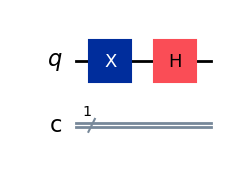

In [5]:
alice_qubits = []

for bit, basis in zip(alice_bits, alice_bases):
    alice_qubits.append(encode_qubit(bit, basis))

print(f'Alice encoded and sent {len(alice_qubits)} qubits.')
alice_qubits[0].draw('mpl')

## Step 4: Eve intercepts, measures, and resends

Eve does not know Alice's bases, so she chooses random bases. If Eve chooses the wrong basis, her measurement may disturb the qubit. That disturbance is what Alice and Bob can detect later.

In [6]:
eve_bases = quantum_random_bits(N)
eve_results = []
qubits_sent_to_bob = []

for qubit, eve_basis in zip(alice_qubits, eve_bases):
    resent_qubit, eve_result = eve_intercept_and_resend(qubit, eve_basis)
    qubits_sent_to_bob.append(resent_qubit)
    eve_results.append(eve_result)

print('Eve bases:      ', ''.join(basis_name(b) for b in eve_bases))
print('Eve results:    ', bit_list_to_string(eve_results))

Eve bases:       +x+x+++++++xxx+++++x++++++xxxx+++++x+xx+x+x++x+xx+xxx++xxxx++x++++++x+xxxx+xx+++
Eve results:     01100110010100010000111001001110100101001110101011100100010011101010110000010101


## Step 5: Bob chooses random bases and measures

Bob receives Eve's resent qubits, not Alice's original qubits.

In [7]:
bob_bases = quantum_random_bits(N)
bob_results = []

for qubit, basis in zip(qubits_sent_to_bob, bob_bases):
    bob_results.append(measure_encoded_qubit(qubit, basis))

print('Bob bases:      ', ''.join(basis_name(b) for b in bob_bases))
print('Bob results:    ', bit_list_to_string(bob_results))

Bob bases:       x+x+xx+++xx++x+xx+x+x++xx++x+++xx+++xxxxx+xxxxxx+x+++xx+x+++++xx+xxx++++xxx++++x
Bob results:     00111010001010010000011001100111000111011110001001110111001010101100110000110100


## Step 6: Alice and Bob sift the key

As usual, Alice and Bob keep only the positions where they used the same basis. However, Eve may have disturbed some of those positions.

In [8]:
matching_positions, alice_key, bob_key = sift_key(
    alice_bits,
    alice_bases,
    bob_bases,
    bob_results
)

print_attacker_table(alice_bits, alice_bases, eve_bases, eve_results, bob_bases, bob_results, matching_positions)

print('\nMatching positions:', matching_positions)
print('Alice sifted key:  ', bit_list_to_string(alice_key))
print('Bob sifted key:    ', bit_list_to_string(bob_key))
print('Sifted key length: ', len(alice_key))

i  A bit  A basis  Eve basis  Eve result  Bob basis  Bob result  Keep?
------------------------------------------------------------------------------
 0   1       x         +          0          x          0        yes
 1   0       +         x          1          +          0        yes
 2   1       +         +          1          x          1        no
 3   0       x         x          0          +          1        no
 4   0       +         +          0          x          1        no
 5   1       +         +          1          x          0        no
 6   1       x         +          1          +          1        no
 7   0       +         +          0          +          0        yes
 8   0       +         +          0          +          0        yes
 9   1       +         +          1          x          0        no
10   0       +         +          0          x          1        no
11   1       x         x          1          +          0        no
12   1       +         x      

## Step 7: Detecting Eve

Alice and Bob reveal a sample of their sifted key. If Eve has disturbed the qubits, the sample should contain more mismatches than the no-attacker version. A simple threshold is used to decide whether to report an attack.

In [9]:
mismatches, error_rate = compare_sample(alice_key, bob_key, SAMPLE_SIZE)

print(f'Sample size checked: {min(SAMPLE_SIZE, len(alice_key))}')
print(f'Mismatches found:    {mismatches}')
print(f'Estimated error rate: {error_rate:.2%}')
print(f'Detection threshold:  {THRESHOLD:.2%}')

if error_rate > THRESHOLD:
    print('Result: ATTACK DETECTED. Alice and Bob should discard the key.')
else:
    print('Result: No attack detected from this sample. Try increasing N if Eve is not detected.')

# In a real BB84 protocol, the revealed sample bits are discarded.
final_alice_key = alice_key[min(SAMPLE_SIZE, len(alice_key)):]
final_bob_key = bob_key[min(SAMPLE_SIZE, len(bob_key)):]

print('\nRemaining Alice key after discarding sample:', bit_list_to_string(final_alice_key))
print('Remaining Bob key after discarding sample:  ', bit_list_to_string(final_bob_key))

Sample size checked: 20
Mismatches found:    4
Estimated error rate: 20.00%
Detection threshold:  20.00%
Result: No attack detected from this sample. Try increasing N if Eve is not detected.

Remaining Alice key after discarding sample: 000001100110010
Remaining Bob key after discarding sample:   100001101100010


## Why the attacker is detected

When Eve measures in the wrong basis, the original quantum state is disturbed. Even when Bob later uses the same basis as Alice, Bob may receive a wrong result because Eve has resent a qubit based on her incorrect measurement. This creates detectable mismatches in the sifted key.